In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")

[2025年02月19日 15时05分03秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [13]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/tests/data/bifurcating.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=100)
fadata.obs.index = [f"cell_{i:03d}" for i in range(fadata.shape[0])]

fadata

[2025年02月19日 15时06分46秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


AnnData object with n_obs × n_vars = 100 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [14]:
fadata.obs["lineage"].value_counts()

lineage
sA -> sB       43
sC -> sEndC    15
sBmid -> sC    12
sD -> sEndD    12
sB -> sBmid    11
sBmid -> sD     7
Name: count, dtype: int64

In [56]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


[2025年02月19日 12时23分16秒] DEBUG    plot_trajectory                                                             
                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         
[2025年02月19日 12时23分17秒] DEBUG    add waypoints shape is (211, 100), finished!                                


AnnData object with n_obs × n_vars = 100 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

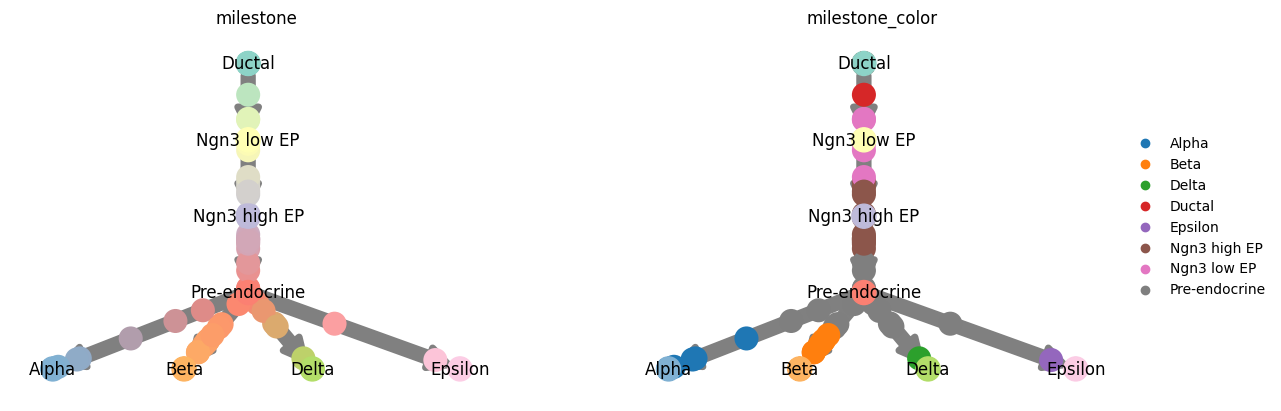

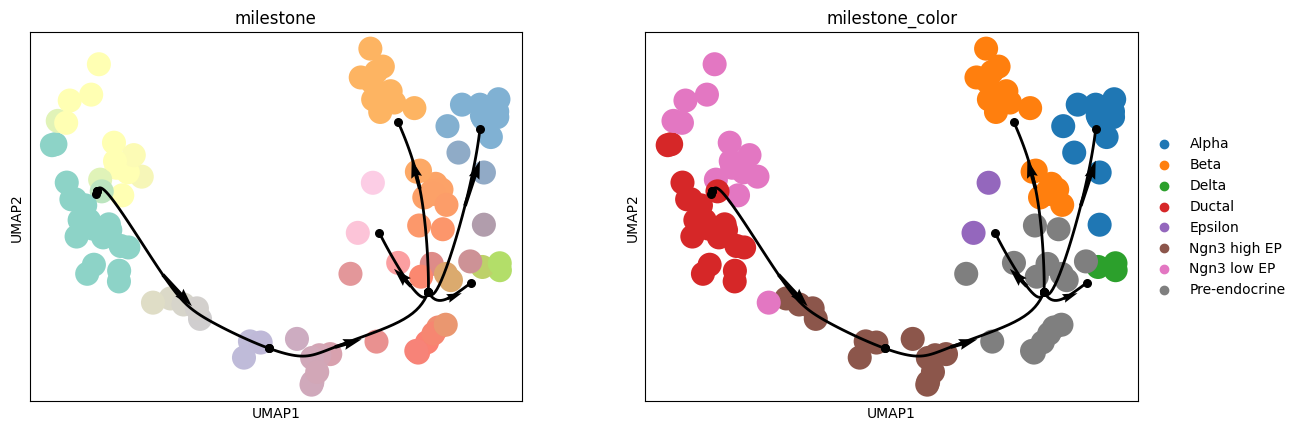

In [57]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

In [58]:
milestone_wrapper = fadata.milestone_wrapper
milestone_wrapper

In [59]:
milestone_wrapper["milestone_network"]

,from,to,length,directed
0,Ductal,Ngn3 low EP,0.726871,True
1,Ngn3 low EP,Ngn3 high EP,8.998320,True
2,Ngn3 high EP,Pre-endocrine,7.650558,True
3,Pre-endocrine,Alpha,6.236413,True
4,Pre-endocrine,Beta,5.807161,True
5,Pre-endocrine,Delta,3.668818,True
6,Pre-endocrine,Epsilon,4.135797,True


In [68]:
cell_mst = cfe.method.FateMethod(method_name="cell_mst")

cell_mst.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key_list)

[2025年02月19日 14时55分57秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_cell_mst at 0x7f93483d5990> from                    
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 cell_mst.py                                                                       
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x7f935eabea10>                                                                   
[2025年02月19日 14时56分00秒] DEBUG    FateAnnData add_trajectory                                                  
[2025年02月19日 15时03分54秒] DEBUG    FateAnnData add_trajectory                                                  
                        DEBUG    plot_trajectory                                          

KeyError: "['milestone_cell_001'] not in index"